#Name: Anush Acharya
#StudentID:2406798
#Worksheet7

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Import Libraries

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import confusion_matrix, classification_report

#2. Load Devnagari Dataset

In [4]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/Copy of devnagari digit.zip'
extraction_path = '/content/devnagari_digits'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"File '{zip_file_path}' unzipped to '{extraction_path}' successfully.")

# List the contents of the extracted directory (folders only)
print("\nContents of the extracted directory (folders only):")
for root, dirs, files in os.walk(extraction_path):
    level = root.replace(extraction_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")


File '/content/drive/MyDrive/Copy of devnagari digit.zip' unzipped to '/content/devnagari_digits' successfully.

Contents of the extracted directory (folders only):
devnagari_digits/
    DevanagariHandwrittenDigitDataset/
        Train/
            digit_4/
            digit_1/
            digit_6/
            digit_7/
            digit_3/
            digit_5/
            digit_9/
            digit_2/
            digit_0/
            digit_8/
        Test/
            digit_4/
            digit_1/
            digit_6/
            digit_7/
            digit_3/
            digit_5/
            digit_9/
            digit_2/
            digit_0/
            digit_8/


In [7]:
data = []
img_size = 32   #


dataset_path = '/content/devnagari_digits/DevanagariHandwrittenDigitDataset/Train'

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)


    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)

            img = Image.open(img_path).convert('L')
            img = img.resize((img_size, img_size))
            img = np.array(img)

            data.append(img)

data = np.array(data)
print("Dataset shape:", data.shape)

Dataset shape: (17000, 32, 32)


#3. Preprocess Data

In [10]:
# Normalize
data = data.astype('float32') / 255.0

# Reshape
data = np.reshape(data, (len(data), img_size, img_size, 1))

# Train-test split
x_train, x_test = train_test_split(data, test_size=0.2, random_state=42)

print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (13600, 32, 32, 1)
Test: (3400, 32, 32, 1)


#4. Add Noise

In [11]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

#5. Visualize Noise

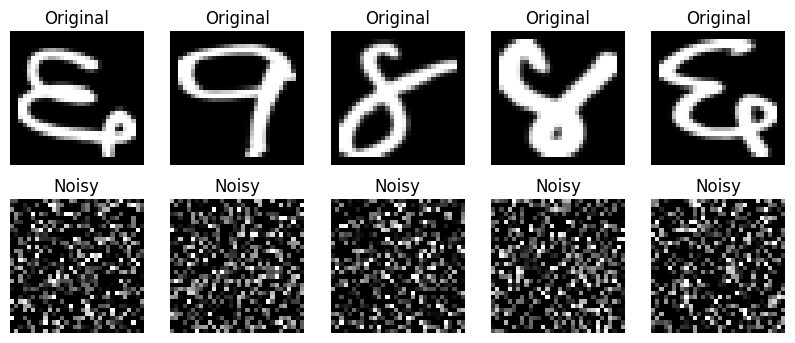

In [12]:
n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_train[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(x_train_noisy[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.show()

#6. Build Autoencoder Model

In [14]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

input_img = Input(shape=(img_size, img_size, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

# Bottleneck (deep representation)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)

# Decoder
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,625 (1.20 MB)

 Trainable params: 314,625 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

#7. Train Model

In [15]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - loss: 0.0379 - val_loss: 0.0075
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - loss: 0.0074 - val_loss: 0.0073
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - loss: 0.0073 - val_loss: 0.0073
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - loss: 0.0073 - val_loss: 0.0073
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - loss: 0.0073 - val_loss: 0.0073
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - loss: 0.0073 - val_loss: 0.0073
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - loss: 0.0073 - val_loss: 0.0073
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - loss: 0.0073 - val_loss: 0.0073
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - loss: 0.0073 - val_loss: 0.0073
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - loss: 0.0073 - val_loss: 0.0073


#8. Plot Loss Graph

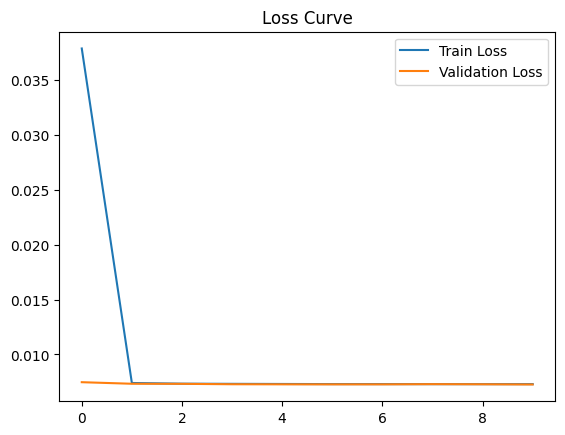

In [16]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

#9. Predict (Denoising)

In [17]:
denoised_images = autoencoder.predict(x_test_noisy)

107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step


#10. Visualize Results

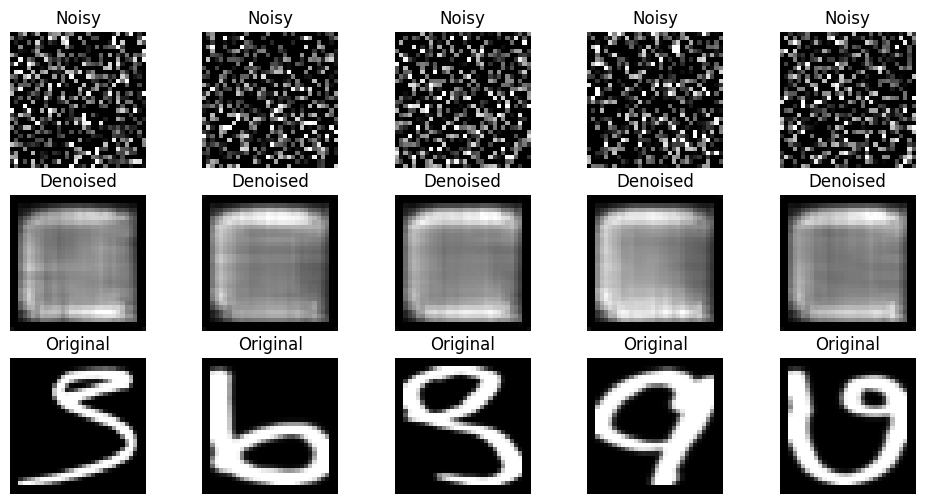

In [18]:
n = 5
plt.figure(figsize=(12,6))

for i in range(n):
    # Noisy
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(denoised_images[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Original
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_test[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.show()